## Life Expectancy Drivers

A look at what actually moves the needle on life expectancy — GDP, health spending, education spending, sanitation, and clean water access — using World Bank data from 2000–2018.

- Part 1 runs a regression to see which of these matters most. 

- Part 2 tracks each country's trend over time and flags who's improving fastest (and who has the most room left to grow)

The indicators to be looked at, and their official World Bank codes:
- LIFE_EXPECTANCY    = "SP.DYN.LE00.IN"      
- GDP_PER_CAPITA      = "NY.GDP.PCAP.CD"      
- HEALTH_SPENDING     = "SH.XPD.CHEX.GD.ZS"   
- EDUCATION_SPENDING  = "SE.XPD.TOTL.GD.ZS"   
- SANITATION_ACCESS   = "SH.STA.SMSS.ZS"      
- WATER_ACCESS        = "SH.H2O.SMDW.ZS"  
- UNDER5_MORTALITY    = "SH.DYN.MORT"     

In [1]:
# list of necessary imports 

import requests                            
import pandas as pd                        
import numpy as np                      
import statsmodels.api as sm            
import matplotlib.pyplot as plt             
from sklearn.linear_model import LinearRegression   

In [2]:
# defining the function to get World Bank indicator data

def get_indicator_range(code, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}"
    params = {
        "date": f"{start_year}:{end_year}",
        "format": "json",
        "per_page": 20000,
    }

    response = requests.get(url, params=params)
    data = response.json()

    # Debug check, print what we got back if it's not shaped how we expect
    if len(data) < 2:
        print(f"Problem with code: {code}")
        print(data)
        return pd.DataFrame()  

    records = data[1]

    rows = []
    for r in records:
        rows.append({
            "country_code": r["countryiso3code"],
            "country": r["country"]["value"],
            "year": int(r["date"]),
            "value": r["value"]
        })

    return pd.DataFrame(rows)

In [3]:
# A dictionary so we can loop through name -> code pairs
indicators = {
    "life_expectancy":     "SP.DYN.LE00.IN",      
    "gdp_per_capita":       "NY.GDP.PCAP.CD",      
    "health_spending":      "SH.XPD.CHEX.GD.ZS",   
    "education_spending":   "SE.XPD.TOTL.GD.ZS",   
    "sanitation_access":    "SH.STA.SMSS.ZS",      
    "water_access":         "SH.H2O.SMDW.ZS",
    "under5_mortality":     "SH.DYN.MORT"
}

start_year = 2015
end_year = 2024

all_data = {}
for name, code in indicators.items():
    df = get_indicator_range(code, start_year, end_year)
    
    if df.empty:
        print(f"Skipping {name} ({code}) -- no data returned")
        all_data[name] = df
        continue
    
    df = df.dropna(subset=["value"])
    df = df.sort_values("year", ascending=False)
    df = df.drop_duplicates(subset="country_code", keep="first")
    all_data[name] = df
    print(f"{name}: {df['country_code'].nunique()} countries have at least one value between {start_year}-{end_year}")

life_expectancy: 261 countries have at least one value between 2015-2024
gdp_per_capita: 257 countries have at least one value between 2015-2024
health_spending: 237 countries have at least one value between 2015-2024
education_spending: 233 countries have at least one value between 2015-2024
sanitation_access: 173 countries have at least one value between 2015-2024
water_access: 176 countries have at least one value between 2015-2024
under5_mortality: 240 countries have at least one value between 2015-2024


In [4]:
merged = all_data["life_expectancy"][["country_code", "country", "value"]].copy()
merged = merged.rename(columns={"value": "life_expectancy"})

for name in ["gdp_per_capita", "health_spending", "education_spending",
             "sanitation_access", "water_access", "under5_mortality"]:
    temp = all_data[name][["country_code", "value"]].rename(columns={"value": name})
    merged = merged.merge(temp, on="country_code", how="left")

merged.head(10)

,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
2,BHS,"Bahamas, The",74.710000,39455.446655,6.302608,2.741916,NaN,NaN,12.4
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
5,BRB,Barbados,76.332000,26897.200204,5.404638,3.555932,NaN,NaN,9.8
6,AGO,Angola,64.805000,2720.819007,2.546929,2.512737,NaN,NaN,49.0
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3
8,UKR,Ukraine,74.692000,5391.622559,8.202748,5.140100,92.393890,87.868377,7.9
9,ARE,United Arab Emirates,83.069000,50273.512624,4.970951,3.894040,98.449700,98.641317,4.8


In [5]:
non_countries = [
    "World", "High income", "Low income", "Middle income",
    "Upper middle income", "Lower middle income", "OECD members",
    "Euro area", "European Union", "Arab World", "East Asia & Pacific",
    "Europe & Central Asia", "Latin America & Caribbean",
    "Middle East & North Africa", "North America", "South Asia",
    "Sub-Saharan Africa", "IDA & IBRD total", "Low & middle income",
    "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)",
    "Least developed countries: UN classification",
]

merged = merged[~merged["country"].isin(non_countries)]

print("Rows before dropping missing values:", {len(merged)})

clean = merged.dropna()

print("Rows after dropping missing values:", {len(clean)})
clean.head()

Rows before dropping missing values: {244}
Rows after dropping missing values: {129}


,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3


In [6]:
clean = clean.copy()  
clean["log_gdp_per_capita"] = np.log(clean["gdp_per_capita"])
clean["log_under5_mortality"] = np.log(clean["under5_mortality"])

In [7]:
clean[["gdp_per_capita", "log_gdp_per_capita", "under5_mortality", "log_under5_mortality"]].head()

,gdp_per_capita,log_gdp_per_capita,under5_mortality,log_under5_mortality
0,58268.878765,10.972823,3.3,1.193922
1,7294.642761,8.894895,17.9,2.884801
3,29717.142461,10.299479,8.8,2.174752
4,2593.416117,7.860731,30.5,3.417727
7,8605.609546,9.060170,2.3,0.832909


In [8]:
clean.describe()

,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality,log_gdp_per_capita,log_under5_mortality
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,74.150821,22778.361651,7.060140,4.287853,61.065356,67.470299,23.516585,9.061374,2.557229
std,7.554875,35563.708169,3.477672,1.950393,29.162151,30.023594,25.363010,1.501456,1.150116
min,54.635000,416.871146,1.326516,0.319069,8.051033,6.217488,1.300000,6.032777,0.262364
25%,68.487000,2593.416117,4.561095,3.229743,33.155693,41.235296,4.700000,7.860731,1.547563
50%,74.965456,8526.296657,6.781033,4.059880,62.174362,74.967263,13.400000,9.050910,2.595255
75%,81.359000,31428.354782,8.507103,5.261660,90.192500,96.890323,36.400000,10.355466,3.594569
max,86.497000,288001.574856,27.089685,16.390530,100.000000,100.000000,115.600000,12.570721,4.750136


In [9]:
clean.sort_values("gdp_per_capita", ascending=False).head(3)[["country", "gdp_per_capita"]]
clean.sort_values("health_spending", ascending=False).head(3)[["country", "health_spending"]]

,country,health_spending
30,Tuvalu,27.089685
189,Naoero,18.210760
11,United States,16.694149


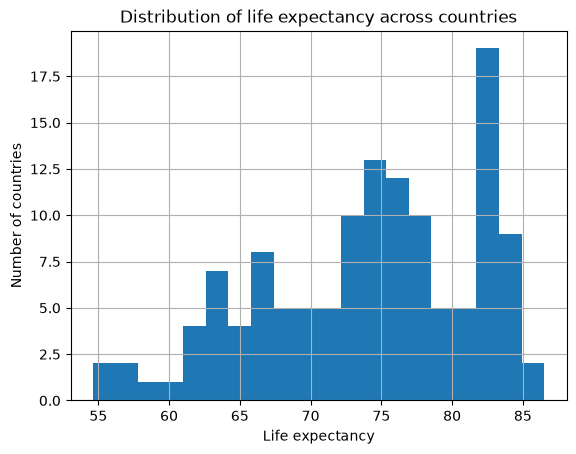

In [10]:
clean["life_expectancy"].hist(bins=20)
plt.xlabel("Life expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of life expectancy across countries")
plt.show()

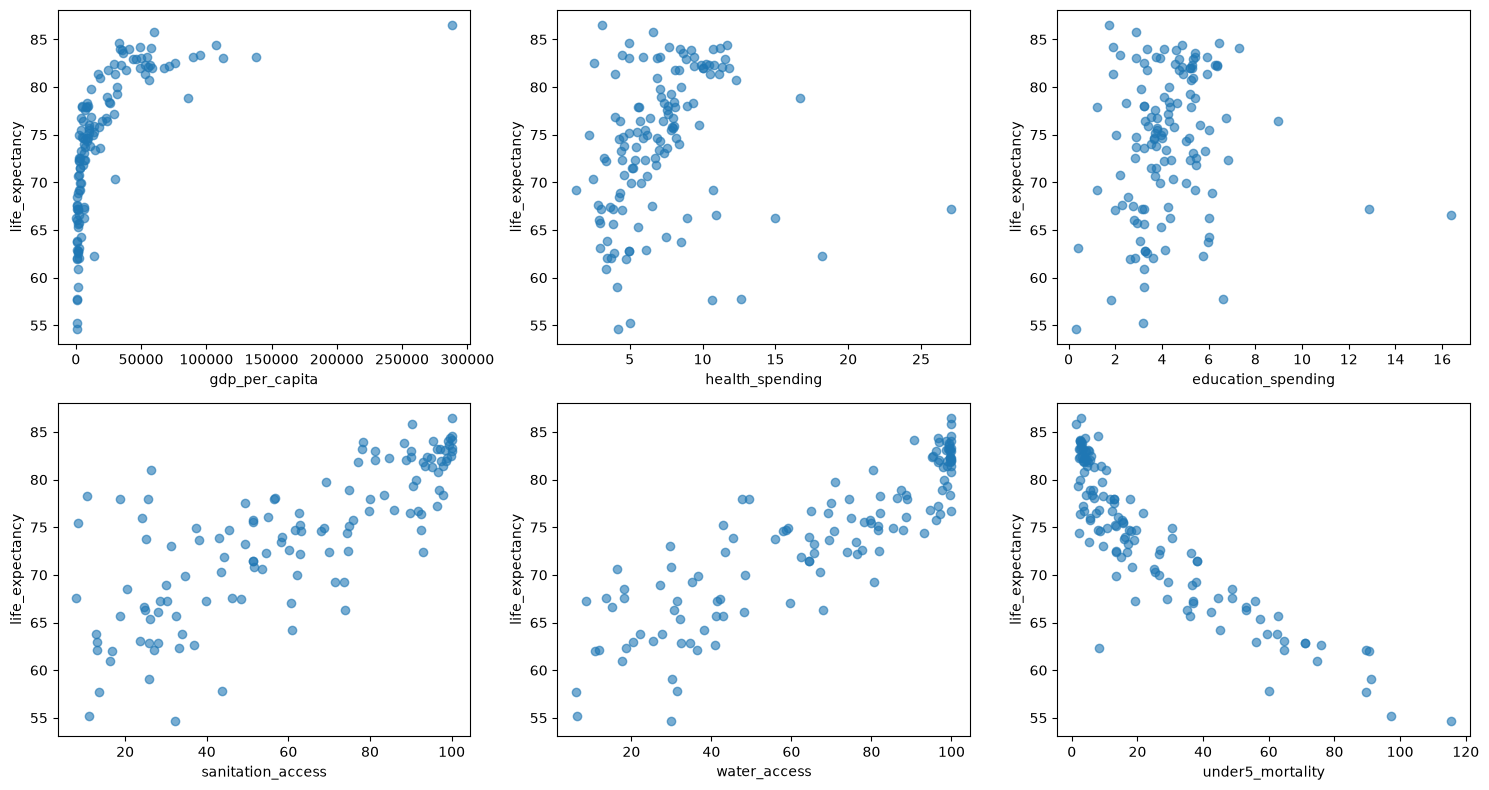

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    ("gdp_per_capita", axes[0, 0]),
    ("health_spending", axes[0, 1]),
    ("education_spending", axes[0, 2]),
    ("sanitation_access", axes[1, 0]),
    ("water_access", axes[1, 1]),
    ("under5_mortality", axes[1, 2]),
]

for column, ax in pairs:
    ax.scatter(clean[column], clean["life_expectancy"], alpha=0.6)
    ax.set_xlabel(column)
    ax.set_ylabel("life_expectancy")

plt.tight_layout()
plt.show()

In [12]:
clean[["life_expectancy", "gdp_per_capita", "health_spending",
       "education_spending", "sanitation_access", "water_access",
       "under5_mortality"]].corr()

,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
life_expectancy,1.000000,0.604249,0.227415,0.113431,0.774074,0.880900,-0.889585
gdp_per_capita,0.604249,1.000000,0.153734,-0.009081,0.569326,0.545782,-0.439674
health_spending,0.227415,0.153734,1.000000,0.562656,0.255904,0.204841,-0.312299
education_spending,0.113431,-0.009081,0.562656,1.000000,0.150452,0.078427,-0.214466
sanitation_access,0.774074,0.569326,0.255904,0.150452,1.000000,0.829710,-0.713689
water_access,0.880900,0.545782,0.204841,0.078427,0.829710,1.000000,-0.796978
under5_mortality,-0.889585,-0.439674,-0.312299,-0.214466,-0.713689,-0.796978,1.000000


### Regression

Now trying to answer the question, which variables actually matter, and by how much.

In [13]:
feature_columns = [
    "log_gdp_per_capita",
    "health_spending",
    "education_spending",
    "sanitation_access",
    "water_access",
    "log_under5_mortality",
]

X = clean[feature_columns]
y = clean["life_expectancy"]

X = sm.add_constant(X)  

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     135.8
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.49e-51
Time:                        22:33:45   Log-Likelihood:                -311.94
No. Observations:                 129   AIC:                             637.9
Df Residuals:                     122   BIC:                             657.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   68.0948 

Raw coefficients above aren't comparable to each other. GDP is in dollars,
water access is a percentage, mortality is a log-transformed rate. To rank
them fairly, everything must be put on the same scale first.

In [ ]:
# Standardizing every column:  (value - mean) / standard deviation
X_features = clean[feature_columns]
X_standardized = (X_features - X_features.mean()) / X_features.std()

y_standardized = (clean["life_expectancy"] - clean["life_expectancy"].mean()) / clean["life_expectancy"].std()

X_standardized = sm.add_constant(X_standardized)
model_standardized = sm.OLS(y_standardized, X_standardized).fit()

importance = model_standardized.params.drop("const")
importance = importance.sort_values(key=abs, ascending=False)

print("Ranked by importance (biggest effect first):")
print(importance)

Ranked by importance (biggest effect first):
log_under5_mortality   -0.480389
water_access            0.340012
log_gdp_per_capita      0.216118
health_spending        -0.097679
sanitation_access      -0.045344
education_spending      0.043032
dtype: float64


Once GDP, education, and health spending are accounted for, the strongest predictors of life expectancy in this sample are under-5 mortality and access to clean water; both roughly 1.5-2x the effect size of GDP per capita. Sanitation access and education spending show no meaningful independent effect once the other variables are included, likely because their signal overlaps heavily with water access and child mortality (as the correlation matrix showed)

### multicollinearity (VIF)

The correlation matrix already hinted that some of these variables overlap a lot (sanitation and water access, for example). VIF puts an actual number on that overlap for each variable.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_with_const = sm.add_constant(clean[feature_columns])

vif_data = pd.DataFrame()
vif_data["variable"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(X_with_const.shape[1])
    ]

vif_data = vif_data[vif_data["variable"] != "const"]

vif_data.sort_values("VIF", ascending=False)

,variable,VIF
6,log_under5_mortality,6.951189
1,log_gdp_per_capita,6.240205
5,water_access,5.422681
4,sanitation_access,3.656554
2,health_spending,1.718531
3,education_spending,1.487027


VIF values for under-5 mortality, GDP per capita, and water access (5.4-7.0) indicate moderate multicollinearity, not severe enough to invalidate the model, but enough that their individual coefficients should be read as 'this cluster of related development indicators matters,' rather than precisely isolating one variable's unique contribution.